# PHASE 3: TARGET VARIABLE ANALYSIS  

## Understand about the target variable

- so far in target variable ['rent']
- removed rows contains NaNs and rent record under 1000

### Dataset: Data/processed/EDA/chennai_pg_cleaned_phase2.csv
### Produced by: Phase 2 cleaning pipeline

In [10]:
import pandas as pd
import matplotlib.pylab as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
from scipy import stats
from pathlib import Path

In [19]:
# Configs
DATA_PATH = Path('../Data/processed/EDA/01_eda_Phase-2_processed.csv')
OUTPUT_DIR = Path('../Data/outputs/eda/phase_3')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = 'muted'
FIG_DPI = 150
STYLE = 'whitegrid'

sns.set_theme(style=STYLE, palette=PALETTE)
plt.rcParams.update({'figure.dpi': FIG_DPI})

In [40]:
# COLUMN SCHEMA (from phase 2 cleaning)

TARGET = 'rent'

NUMERIC_FEATURES = [
    'deposit',
    'transit_score',
    'lifestyle_score',
]

CATEGORICAL_FEATURES = [
    'locality',
    'gender',
    'available_for',
    'occupancy',
    'parking'
]

BOOLEAN_FEATURES = [
    'attached_bathroom',
    'food_included',
    'breakfast',
    'lunch',
    'dinner',
    'mess',
    'wifi',
    'laundry',
    'power_backup',
    'refrigerator',
    'common_tv',
    'room_cleaning',
    'room_ac',
    'room_cupboard',
    'room_tv',
    'room_geyser',
    'room_bedding',
    'room_attached_bath',
]

INDICATOR_FEATURES = [
    'transit_score_missing',
    'lifestyle_score_missing',
]

In [4]:
# Load dataset from phase 2
df = pd.read_csv(DATA_PATH)
print(f'Loaded dataset: {df.shape[0]} rows x {df.shape[1]} columns')

Loaded dataset: 1471 rows x 31 columns


In [5]:
# helper functions

def save(fig: plt.Figure, name: str) -> None:
    path = OUTPUT_DIR / f'{name}.png'
    fig.savefig(path, bbox_inches = 'tight')
    plt.close(fig)
    print(f'Saved: {path.name}')

## 3.1 TARGET VARIABLE ANALYSIS

In [6]:
# Rent stats and skewness
summary = df[TARGET].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.90, 0.99])
skewness = df[TARGET].skew()
kurtosis = df[TARGET].kurt()

print(summary.to_string())
print(f'\nSkewness: {skewness}')
print(f'Kurtosis: {kurtosis}')

count     1471.00000
mean      7779.39225
std       3321.23245
min       1500.00000
5%        4000.00000
25%       6000.00000
50%       7000.00000
75%       8500.00000
90%      11500.00000
99%      19500.00000
max      65000.00000

Skewness: 4.924613672258534
Kurtosis: 64.0672029235691


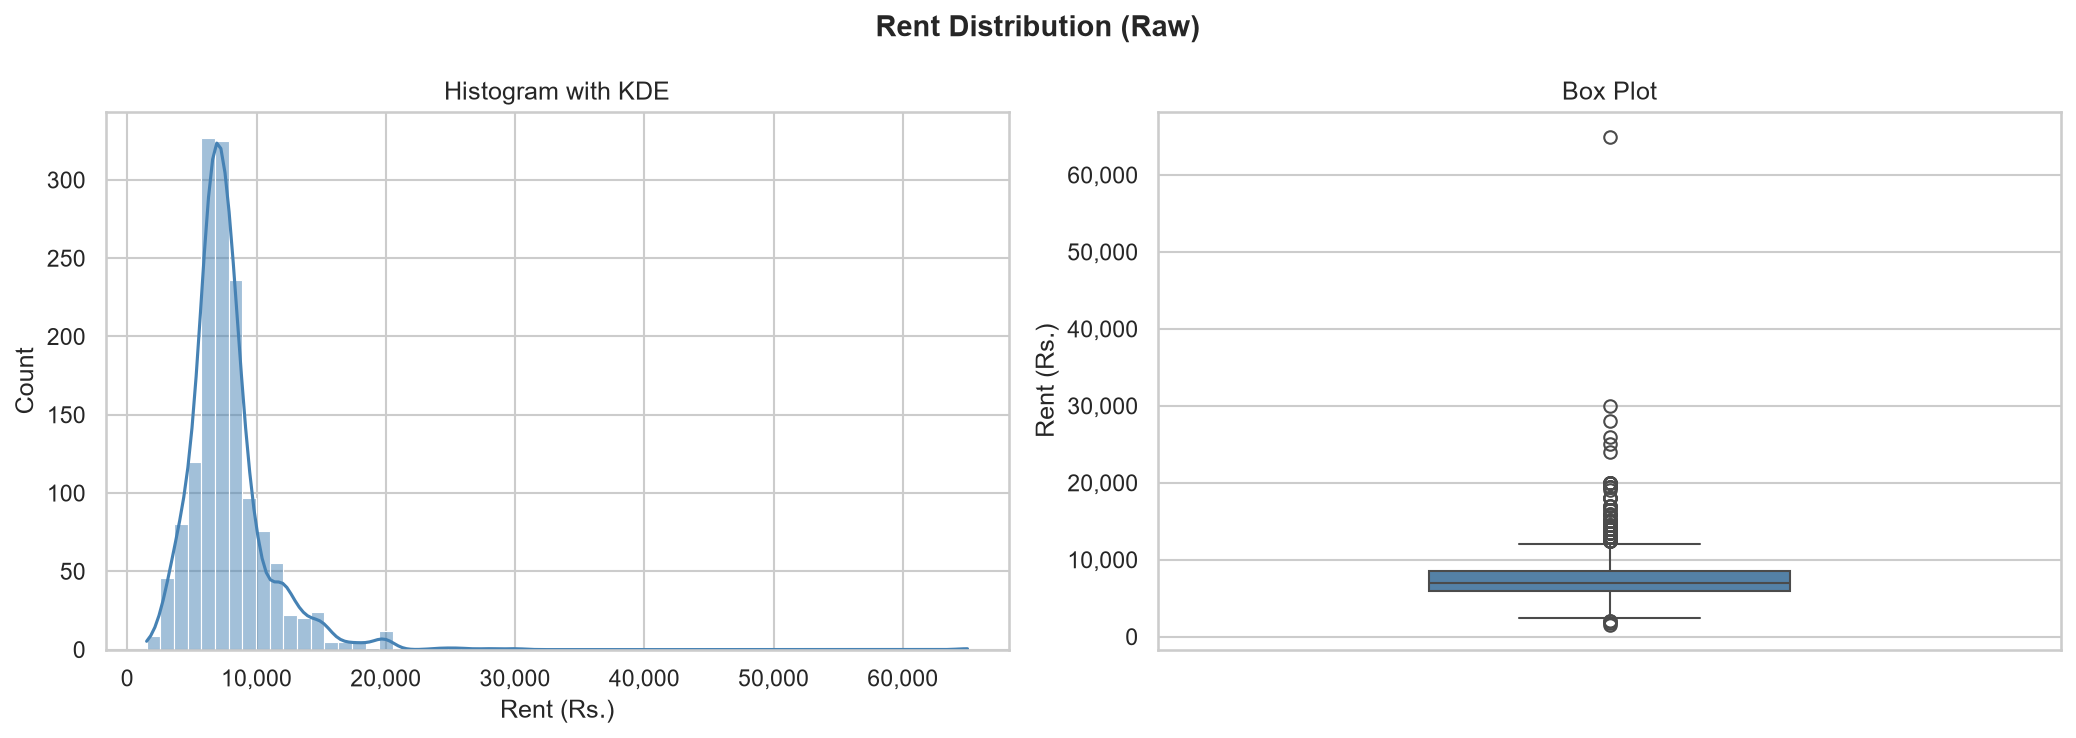

Saved: 01_rent-Distribution_raw.png


In [9]:
# 3.1 Rent distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rent Distribution (Raw)', fontsize=14, fontweight='bold')

# histplot + KDE

sns.histplot(df[TARGET], bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Histogram with KDE')
axes[0].set_xlabel('Rent (Rs.)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# BoxPlot
sns.boxplot(y=df[TARGET], ax=axes[1], color='steelblue', width=0.4)
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Rent (Rs.)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()
save(fig, '01_rent-Distribution_raw')

Log-rent skewness : 0.1973
Log-rent kurtosis : 2.4930


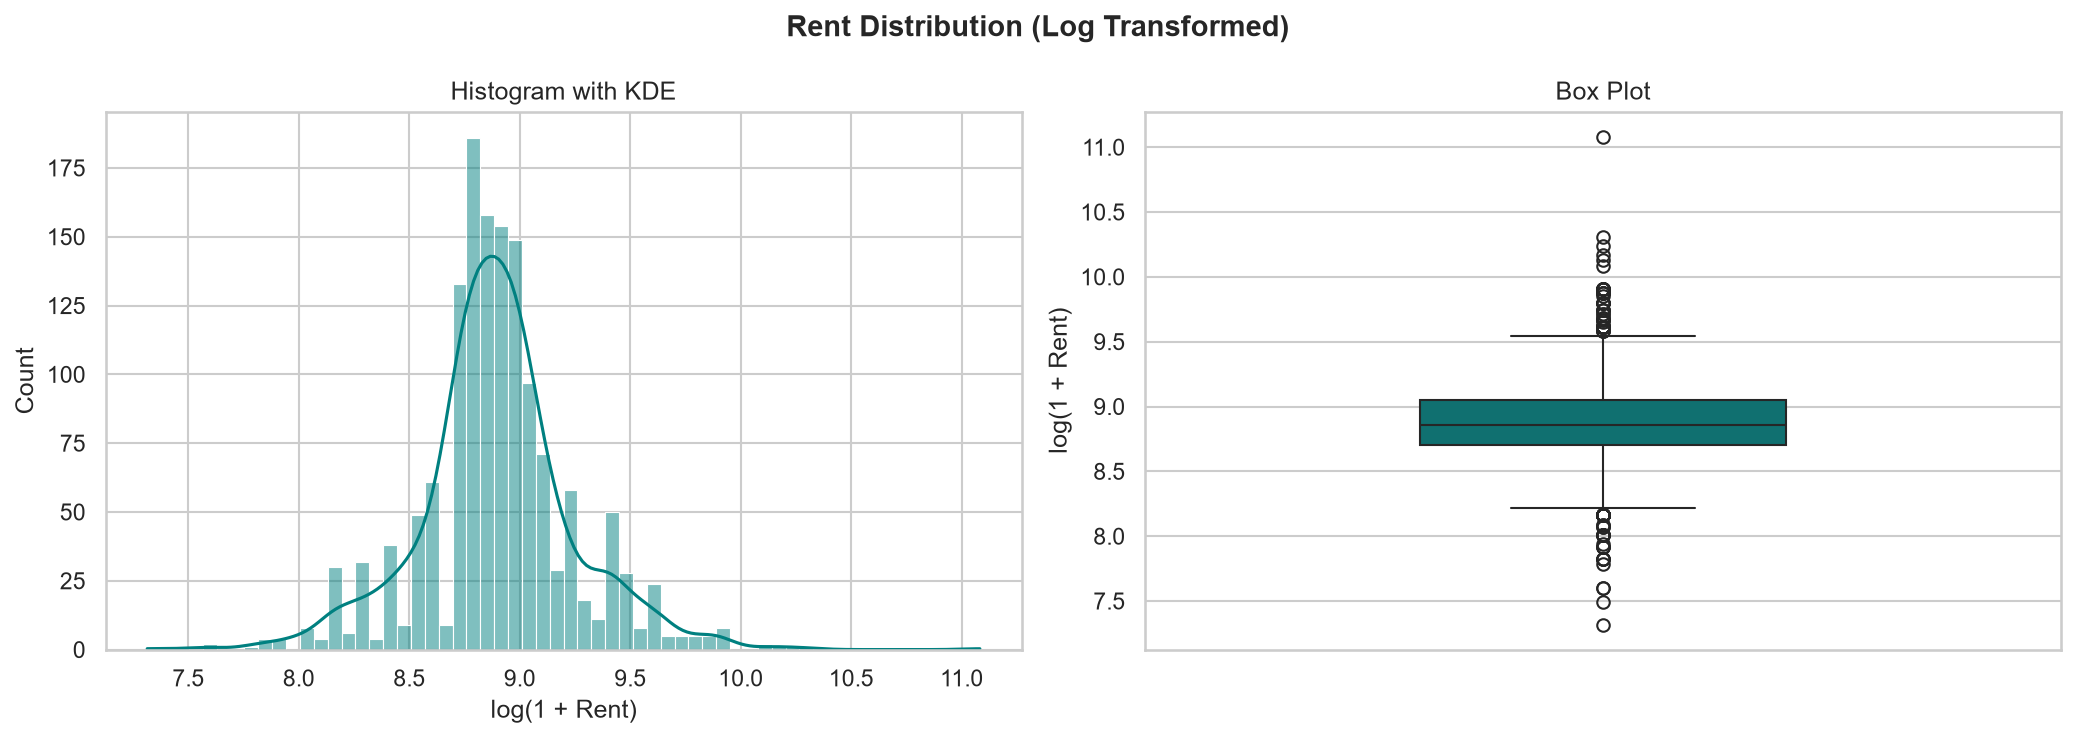

Saved: 02_rent_distribution_log.png


In [13]:
# 3.2 Distribution: log-transformed rent

log_rent = np.log1p(df['rent'])
log_skew = log_rent.skew()
log_kurt = log_rent.kurt()
print(f'Log-rent skewness : {log_skew:.4f}')
print(f'Log-rent kurtosis : {log_kurt:.4f}')
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rent Distribution (Log Transformed)', fontsize=14, fontweight='bold')
 
sns.histplot(log_rent, bins=60, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Histogram with KDE')
axes[0].set_xlabel('log(1 + Rent)')
 
sns.boxplot(y=log_rent, ax=axes[1], color='teal', width=0.4)
axes[1].set_title('Box Plot')
axes[1].set_ylabel('log(1 + Rent)')

plt.tight_layout()
plt.show()
save(fig, '02_rent_distribution_log')

In [ ]:
# 3.3 Normality test

sample = df[TARGET].sample(min(2000, len(df)), random_state=42)
stat, p = stats.shapiro(sample)
print(f'Statistic : {stat:.6f}')
print(f'p-value   : {p:.6e}')
print('Interpretation: rent is NOT normally distributed.' if p < 0.05
      else 'Interpretation: cannot reject normality.')


Statistic : 0.735089
p-value   : 2.363714e-43
Interpretation: rent is NOT normally distributed.


In [ ]:
# 3.4 Outlier inspection

Q1   = df[TARGET].quantile(0.25)
Q3   = df[TARGET].quantile(0.75)
IQR  = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
 
outliers = df[(df[TARGET] < lower_fence) | (df[TARGET] > upper_fence)]
 
print(f'Q1             : Rs. {Q1:,.0f}')
print(f'Q3             : Rs. {Q3:,.0f}')
print(f'IQR            : Rs. {IQR:,.0f}')
print(f'Lower fence    : Rs. {lower_fence:,.0f}')
print(f'Upper fence    : Rs. {upper_fence:,.0f}')
print(f'Outlier rows   : {len(outliers):,}  ({len(outliers)/len(df)*100:.2f}%)')

Q1             : Rs. 6,000
Q3             : Rs. 8,500
IQR            : Rs. 2,500
Lower fence    : Rs. 2,250
Upper fence    : Rs. 12,250
Outlier rows   : 104  (7.07%)


C:\Users\Dinesh\AppData\Local\Temp\ipykernel_17864\1583381050.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='occupancy', y=TARGET, order=occ_order, ax=ax, palette=PALETTE)


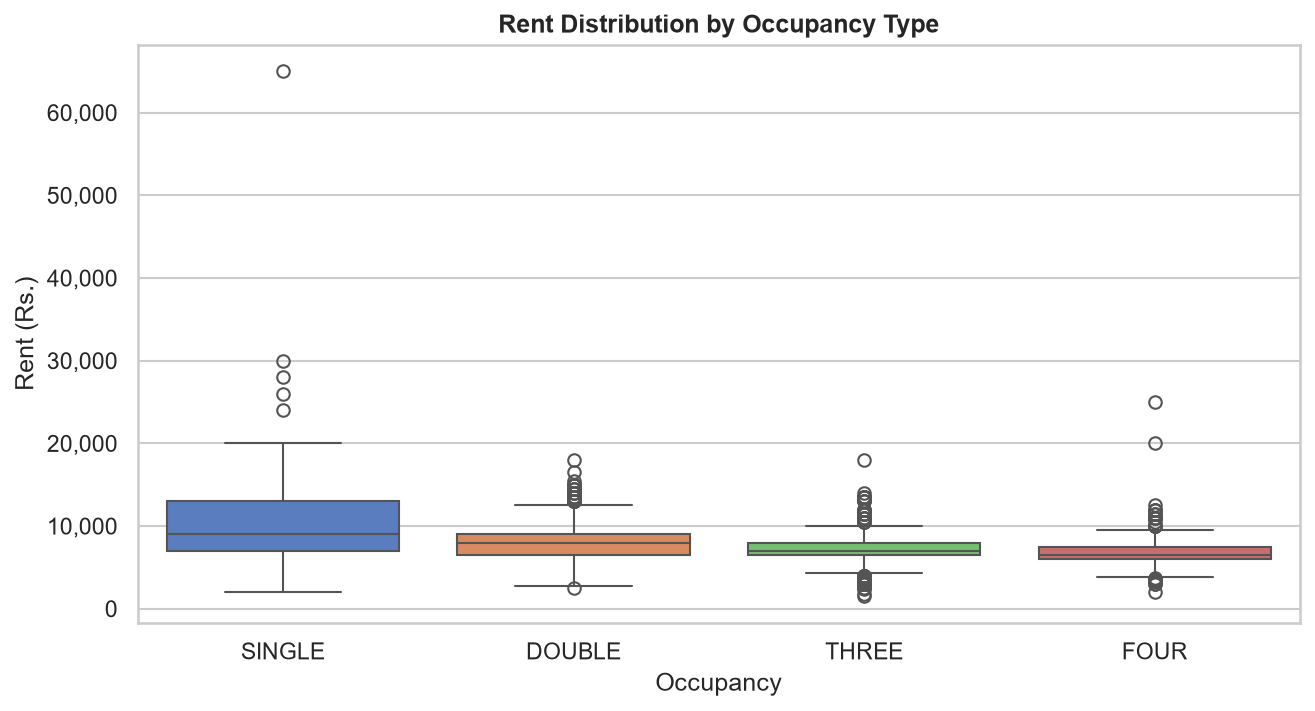

Saved: 03_rent_by_occupancy.png


In [ ]:
# 3.5 Rent by occupancy

occ_order = (
    df.groupby('occupancy')[TARGET].median()
    .sort_values(ascending=False)
    .index.tolist()
)
 
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='occupancy', y=TARGET, order=occ_order, ax=ax, palette=PALETTE)
ax.set_title('Rent Distribution by Occupancy Type', fontweight='bold')
ax.set_xlabel('Occupancy')
ax.set_ylabel('Rent (Rs.)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.show()
save(fig, '03_rent_by_occupancy')


# PHASE 3.2: FEATURE BY FEATURE ANALYSIS: NUMERIC FEATURES

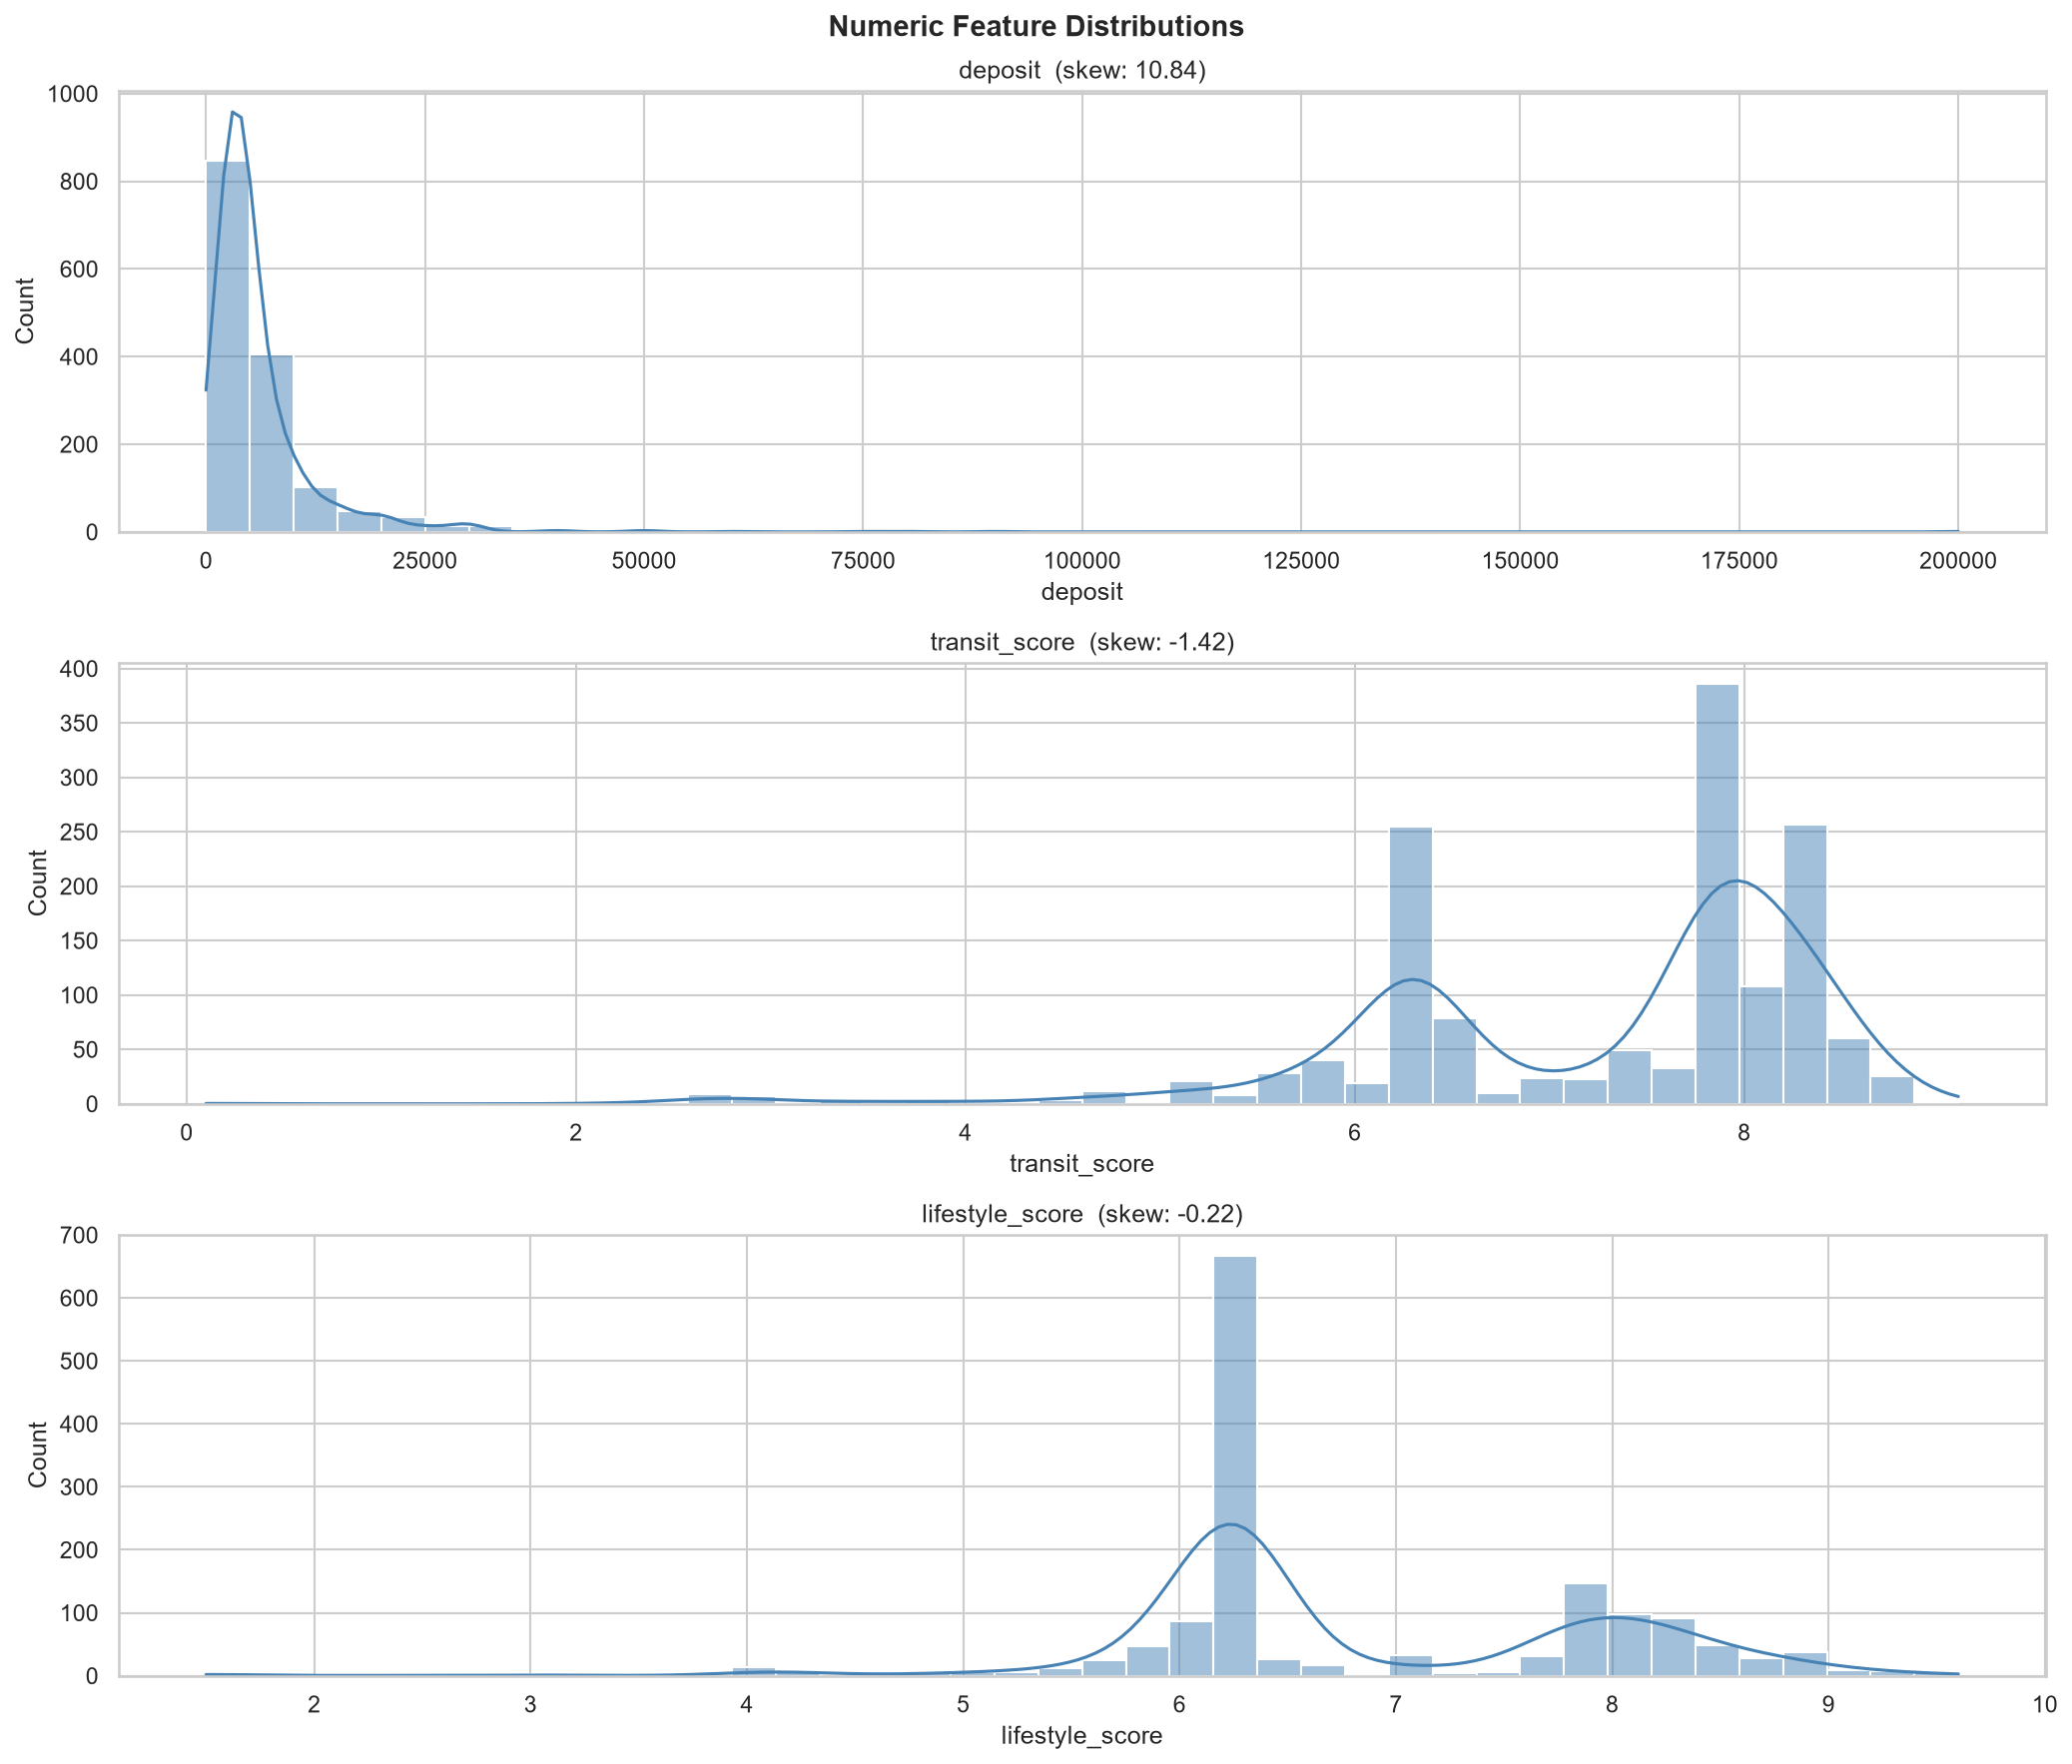

Saved: 04_numeric_distributions.png


In [ ]:
# 1. Distribution Overview: All Numeric Features

available_numeric = [c for c in NUMERIC_FEATURES if c in df.columns]
n_cols = 1
n_rows = int(np.ceil(len(available_numeric) / n_cols))
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
fig.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
axes = axes.flatten()
 
for i, col in enumerate(available_numeric):
    sns.histplot(df[col].dropna(), bins=40, kde=True, ax=axes[i], color='steelblue')
    skew_val = df[col].skew()
    axes[i].set_title(f'{col}  (skew: {skew_val:.2f})')
    axes[i].set_xlabel(col)
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.tight_layout()
plt.show()
save(fig, '04_numeric_distributions')

In [ ]:
# 2. Summary Statistics: Numeric Features

num_summary = df[available_numeric].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
).T
num_summary['skewness'] = df[available_numeric].skew()
num_summary['missing%'] = df[available_numeric].isna().mean() * 100
 
print(num_summary.to_string())

                  count         mean          std  min      5%     25%     50%     75%      95%       max   skewness  missing%
deposit          1471.0  6104.529572  8440.182610  0.0  2000.0  3000.0  4000.0  6000.0  18000.0  200000.0  10.841171       0.0
transit_score    1471.0     7.282495     1.130875  0.1     5.5     6.3     7.8     8.0      8.5       9.1  -1.424704       0.0
lifestyle_score  1471.0     6.828824     1.107419  1.5     5.7     6.2     6.3     7.8      8.6       9.6  -0.216025       0.0


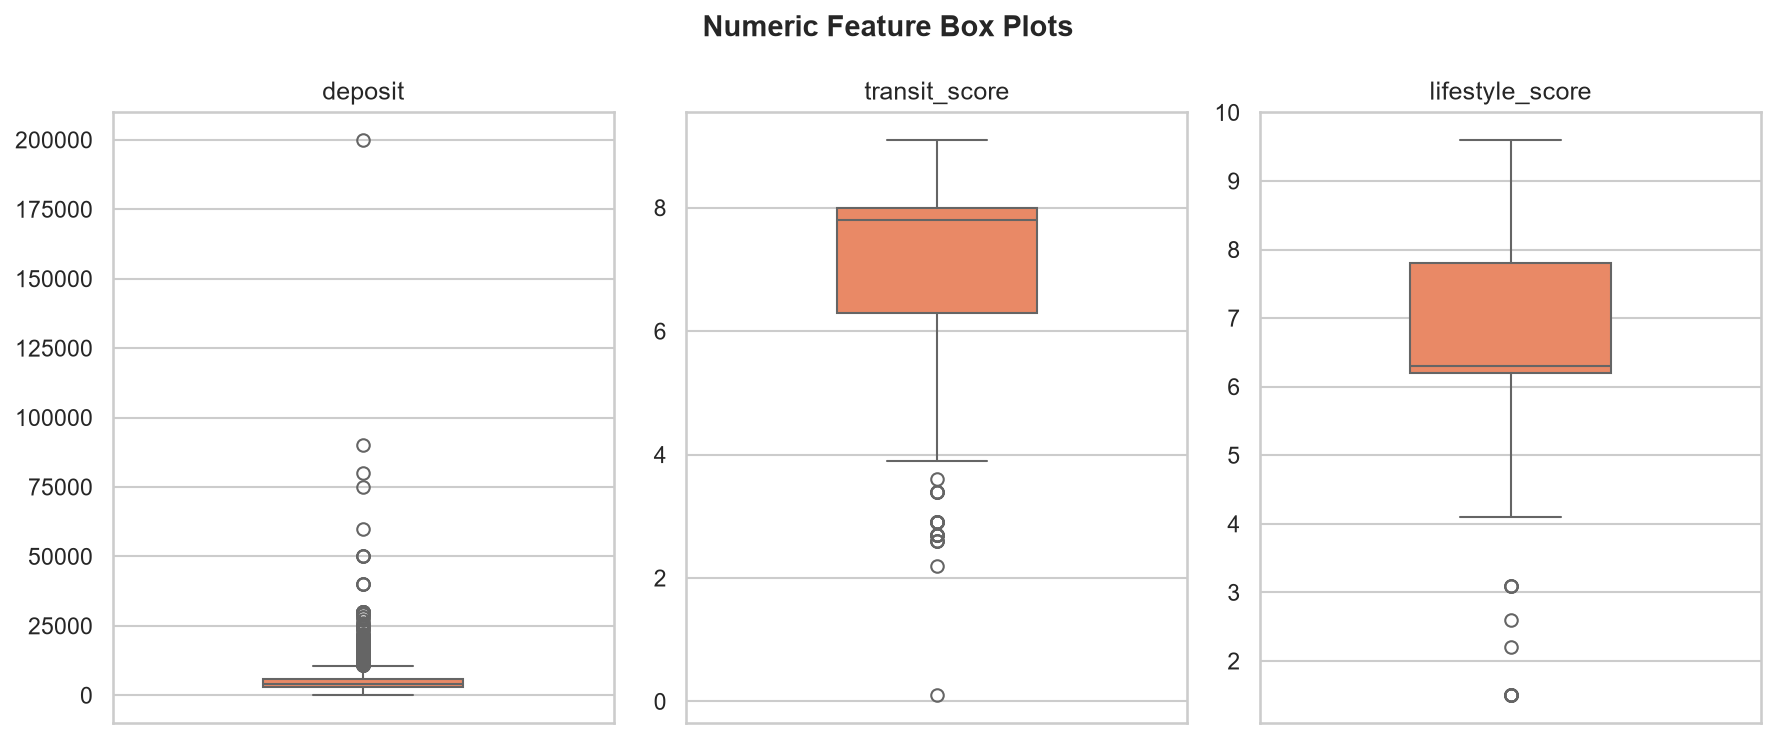

Saved: 05_numeric_boxplots.png


In [30]:
# 3. Box plots: outlier check

fig, axes = plt.subplots(1, len(available_numeric), figsize=(4 * len(available_numeric), 5))
fig.suptitle('Numeric Feature Box Plots', fontsize=14, fontweight='bold')
 
if len(available_numeric) == 1:
    axes = [axes]
 
for ax, col in zip(axes, available_numeric):
    sns.boxplot(y=df[col].dropna(), ax=ax, color='coral', width=0.4)
    ax.set_title(col)
    ax.set_ylabel('')

plt.tight_layout()
plt.show()
save(fig, '05_numeric_boxplots')

count      1471.000000
mean       6104.529572
std        8440.182610
min           0.000000
25%        3000.000000
50%        4000.000000
75%        6000.000000
max      200000.000000

Correlation with rent: 0.4401

Deposit/Rent ratio summary:
count    1471.000000
mean        0.762849
std         0.671898
min         0.000000
25%         0.400000
50%         0.500000
75%         1.000000
max         9.375000


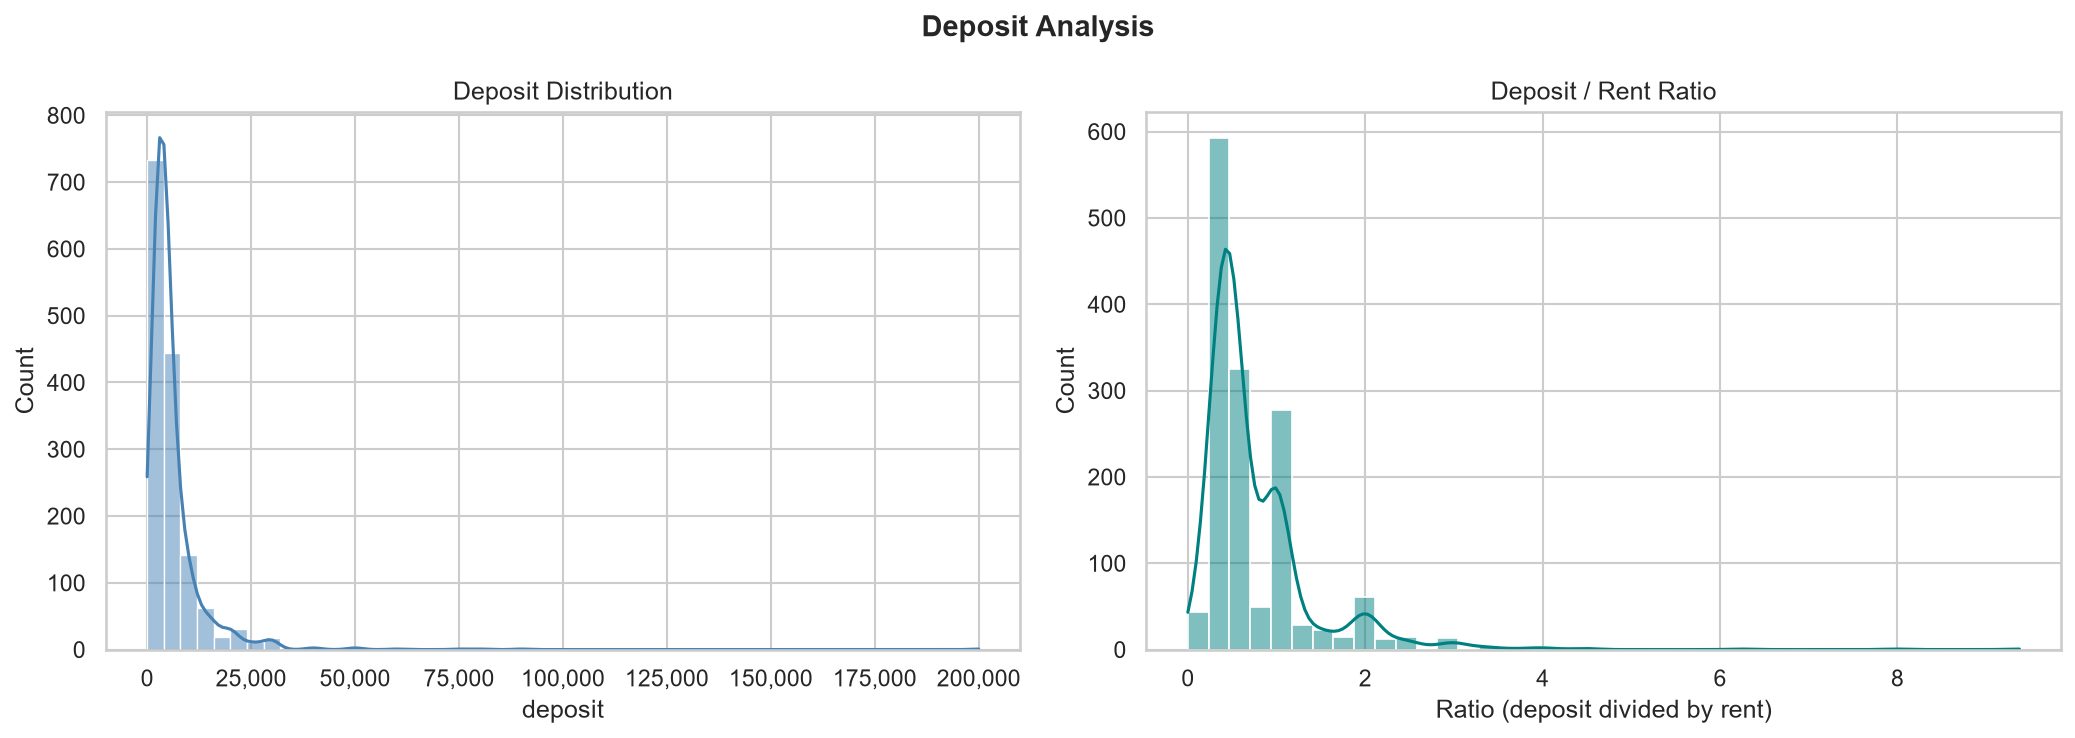

Saved: 06_deposit_analysis.png


In [33]:
# 4. deposit vs rent scatter

if 'deposit' in df.columns:

    print(df['deposit'].describe().to_string())
    print(f'\nCorrelation with rent: {df["deposit"].corr(df[TARGET]):.4f}')
 
    # deposit / rent ratio
    df['deposit_rent_ratio'] = df['deposit'] / df[TARGET]
    print(f'\nDeposit/Rent ratio summary:')
    print(df['deposit_rent_ratio'].describe().to_string())
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Deposit Analysis', fontsize=14, fontweight='bold')
 
    sns.histplot(df['deposit'], bins=50, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('Deposit Distribution')
    axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
 
    sns.histplot(df['deposit_rent_ratio'], bins=40, kde=True, ax=axes[1], color='teal')
    axes[1].set_title('Deposit / Rent Ratio')
    axes[1].set_xlabel('Ratio (deposit divided by rent)')

    plt.tight_layout()
    plt.show()
    save(fig, '06_deposit_analysis')
 
    df.drop(columns=['deposit_rent_ratio'], inplace=True)


count    1471.000000
mean        7.282495
std         1.130875
min         0.100000
25%         6.300000
50%         7.800000
75%         8.000000
max         9.100000
Missing originally: 768 rows


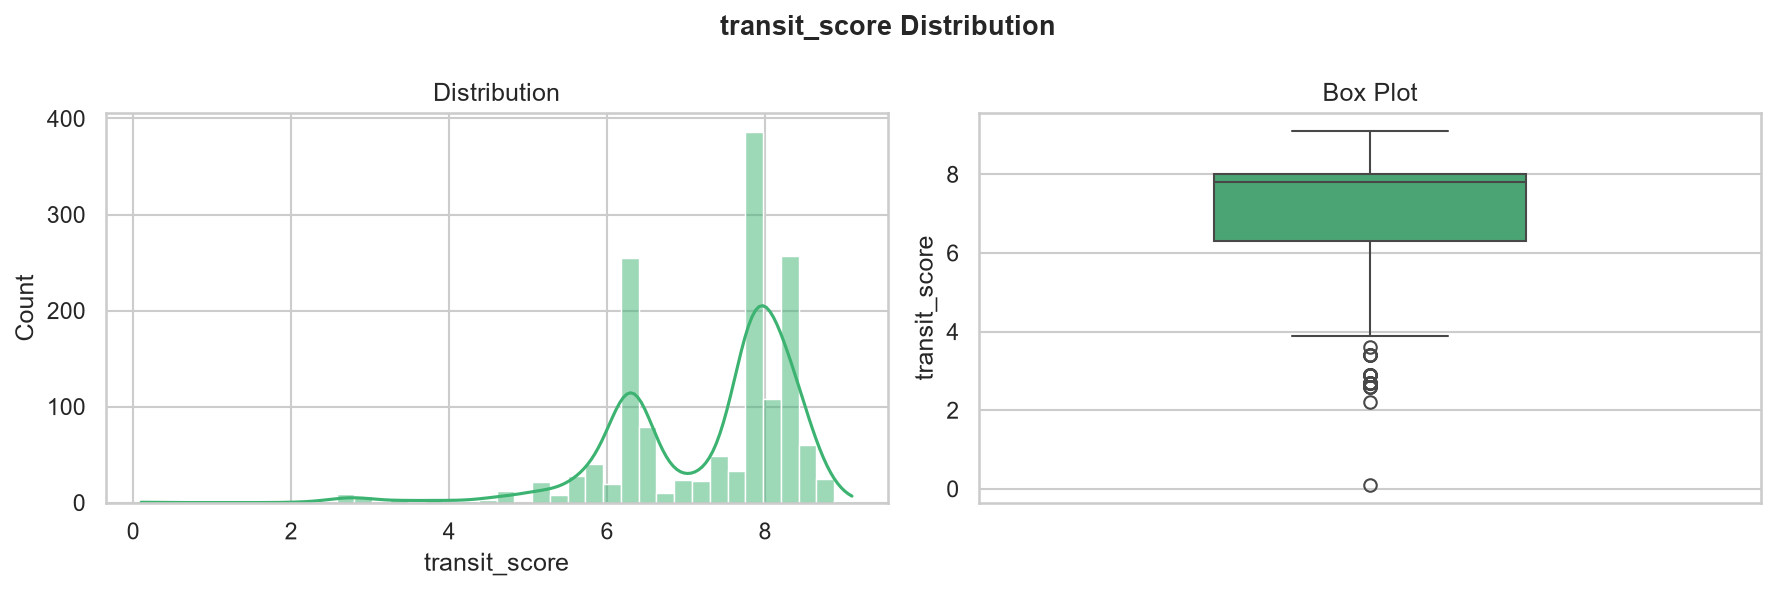

Saved: 07_transit_score_distribution.png
count    1471.000000
mean        6.828824
std         1.107419
min         1.500000
25%         6.200000
50%         6.300000
75%         7.800000
max         9.600000
Missing originally: 761 rows


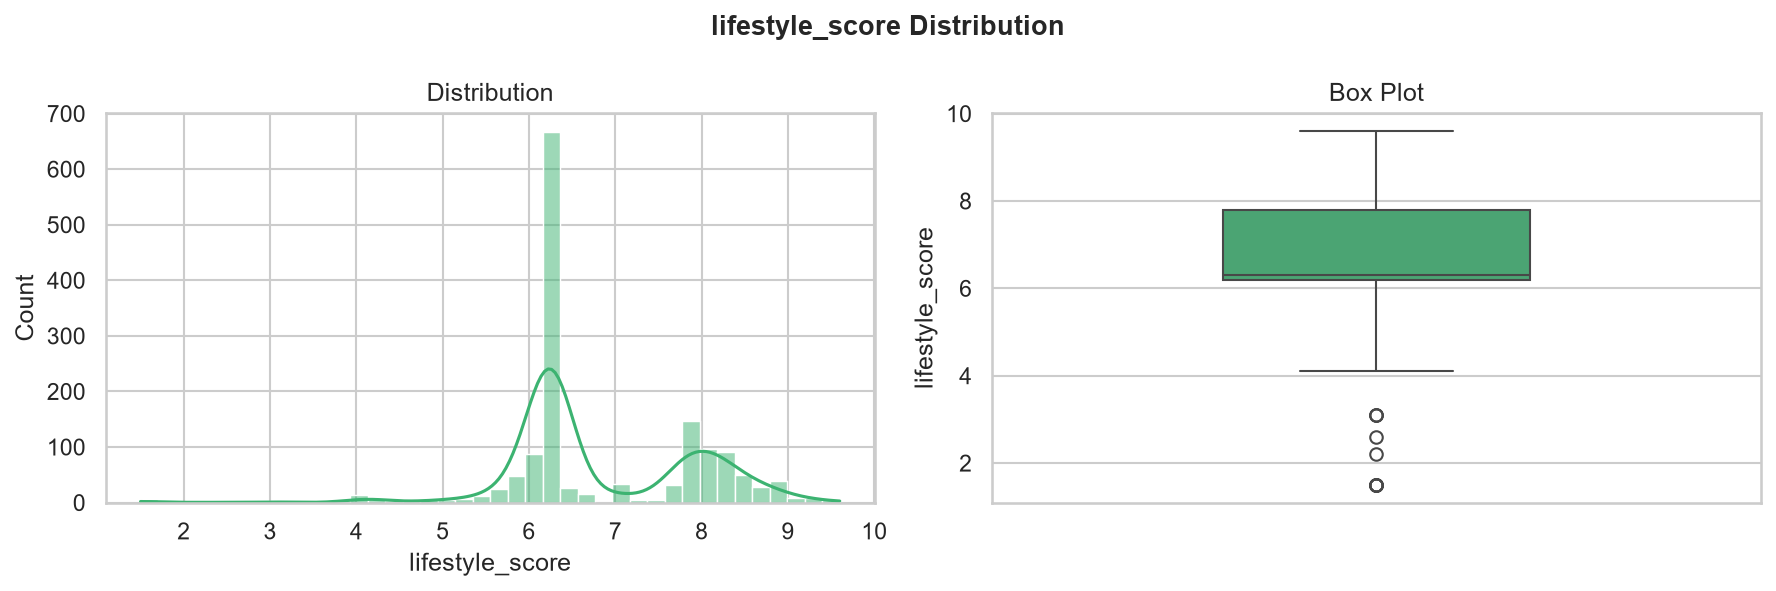

Saved: 07_lifestyle_score_distribution.png


In [34]:
# 4. transit_score and lifestyle_score

for score_col in ['transit_score', 'lifestyle_score']:
    if score_col in df.columns:
        print(df[score_col].describe().to_string())
        print(f'Missing originally: {df[score_col.replace("score", "score_missing")].sum()} rows'
              if f'{score_col}_missing' in df.columns else '')
 
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle(f'{score_col} Distribution', fontsize=13, fontweight='bold')
 
        sns.histplot(df[score_col], bins=40, kde=True, ax=axes[0], color='mediumseagreen')
        axes[0].set_title('Distribution')
 
        sns.boxplot(y=df[score_col], ax=axes[1], color='mediumseagreen', width=0.4)
        axes[1].set_title('Box Plot')

        plt.tight_layout()
        plt.show()
        save(fig, f'07_{score_col}_distribution')


# PHASE 3.3: FEATURE BY FEATURE ANALYSIS: CATEGORICAL FEATURES

                               Count  Percent
locality                                     
Tharamani                        240    16.32
OMR-Karappakam                   232    15.77
Velachery                        192    13.05
Sholinganallur                    94     6.39
Tambaram                          63     4.28
East Coast Road-Thiruvanmiyur     63     4.28
Saidapet                          61     4.15
Vadapalani                        54     3.67
New Perungalathur                 47     3.20
Karapakkam                        44     2.99
Thiruvanmiyur                     40     2.72
East Tambaram                     34     2.31
OMR-Sholinganallur                28     1.90
Arcot Road-Kodambakkam            28     1.90
Guindy                            27     1.84
Perungalathur                     24     1.63
Adambakkam                        24     1.63
Balaji Nagar                      22     1.50
Tambaram West                     22     1.50
Alandur                           

C:\Users\Dinesh\AppData\Local\Temp\ipykernel_17864\2207376168.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.index.astype(str), y=top_vals.values, ax=ax, palette=PALETTE)


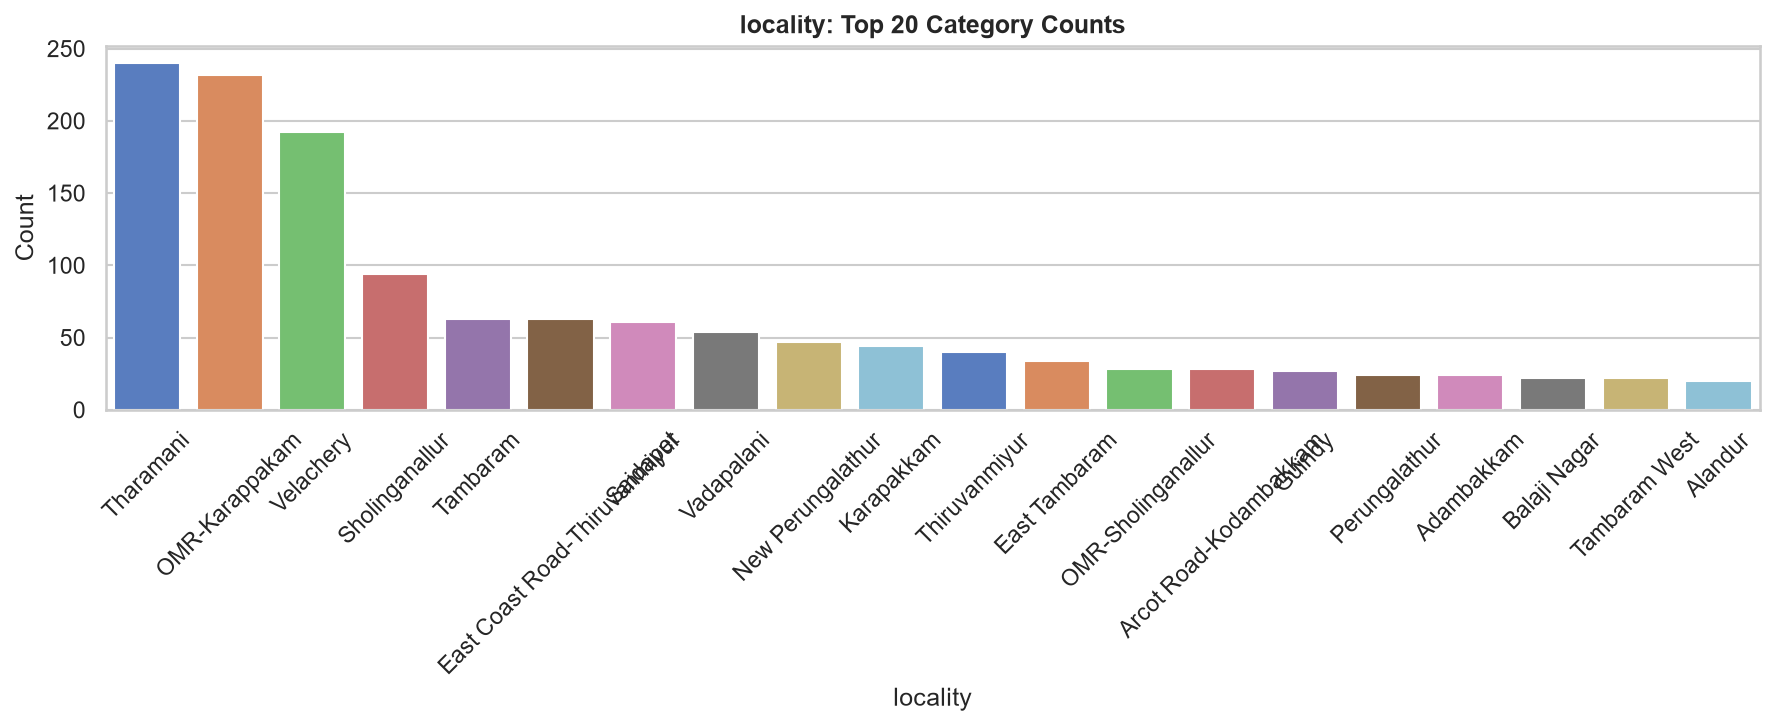

Saved: 08_cat_locality_counts.png
        Count  Percent
gender                
MALE      770    52.35
FEMALE    661    44.94
BOTH       40     2.72

Cardinality: 3 unique values
Missing    : 0 rows  (0.00%)


C:\Users\Dinesh\AppData\Local\Temp\ipykernel_17864\2207376168.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.index.astype(str), y=top_vals.values, ax=ax, palette=PALETTE)


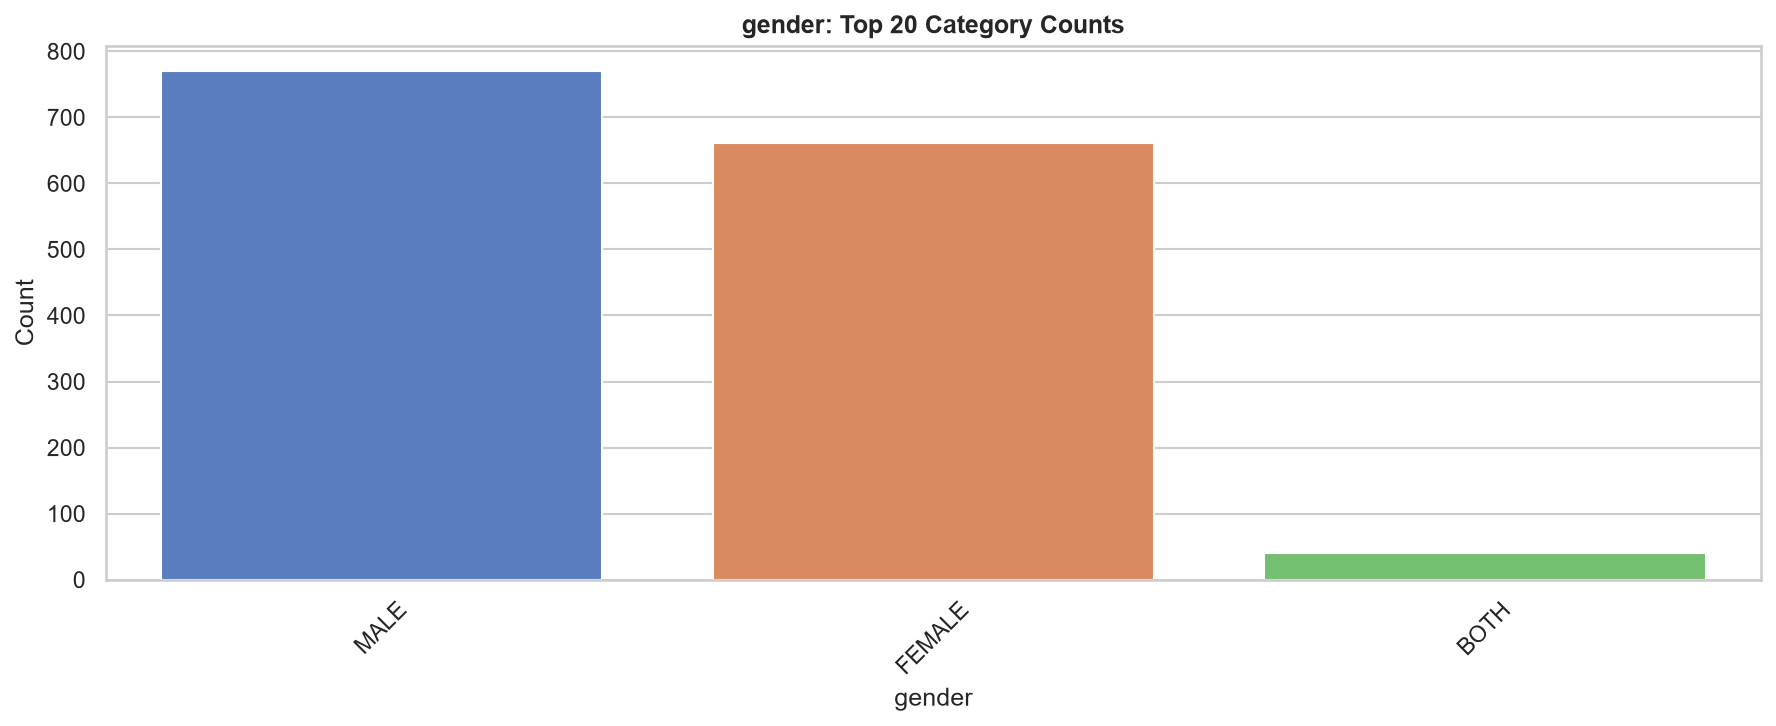

Saved: 08_cat_gender_counts.png
                      Count  Percent
available_for                       
Both                   1307    88.85
Working Professional    139     9.45
Student                  25     1.70

Cardinality: 3 unique values
Missing    : 0 rows  (0.00%)


C:\Users\Dinesh\AppData\Local\Temp\ipykernel_17864\2207376168.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.index.astype(str), y=top_vals.values, ax=ax, palette=PALETTE)


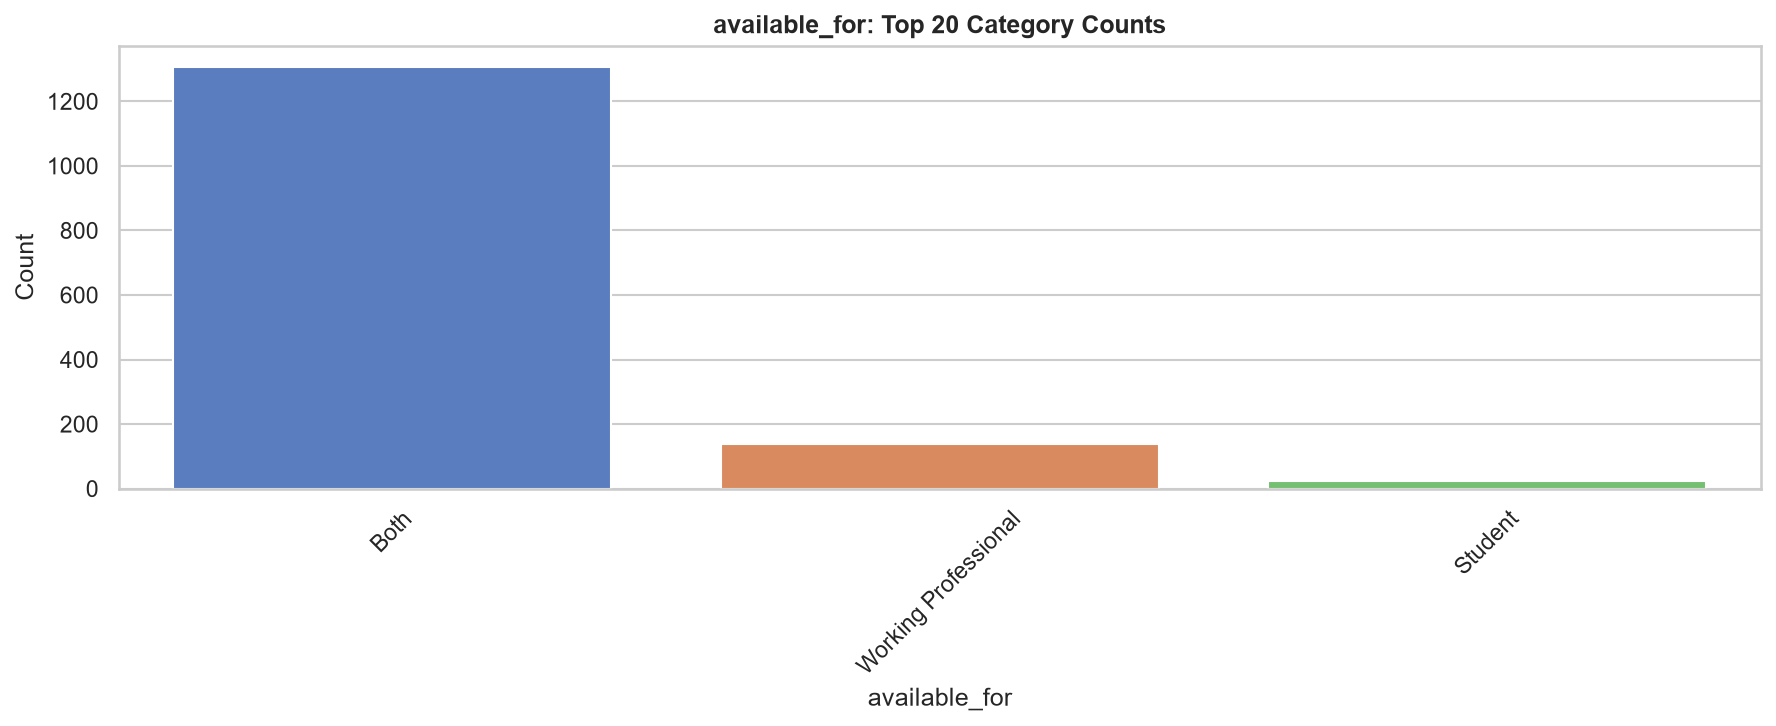

Saved: 08_cat_available_for_counts.png
           Count  Percent
occupancy                
THREE        476    32.36
FOUR         402    27.33
DOUBLE       399    27.12
SINGLE       194    13.19

Cardinality: 4 unique values
Missing    : 0 rows  (0.00%)


C:\Users\Dinesh\AppData\Local\Temp\ipykernel_17864\2207376168.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.index.astype(str), y=top_vals.values, ax=ax, palette=PALETTE)


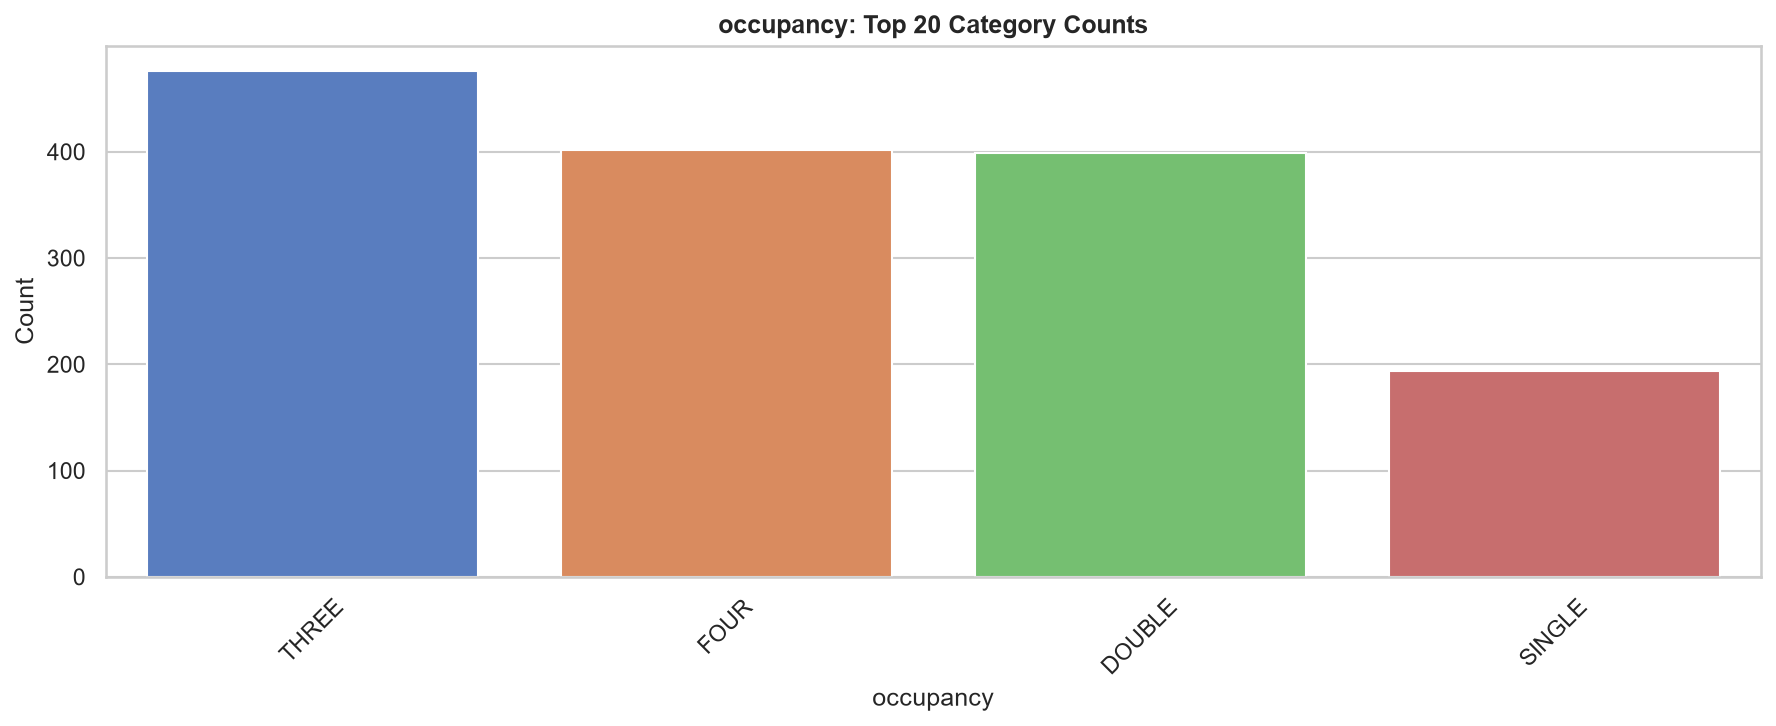

Saved: 08_cat_occupancy_counts.png
              Count  Percent
parking                     
Bike           1170    79.54
NaN             144     9.79
Bike and Car    109     7.41
Car              48     3.26

Cardinality: 3 unique values
Missing    : 144 rows  (9.79%)


C:\Users\Dinesh\AppData\Local\Temp\ipykernel_17864\2207376168.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.index.astype(str), y=top_vals.values, ax=ax, palette=PALETTE)


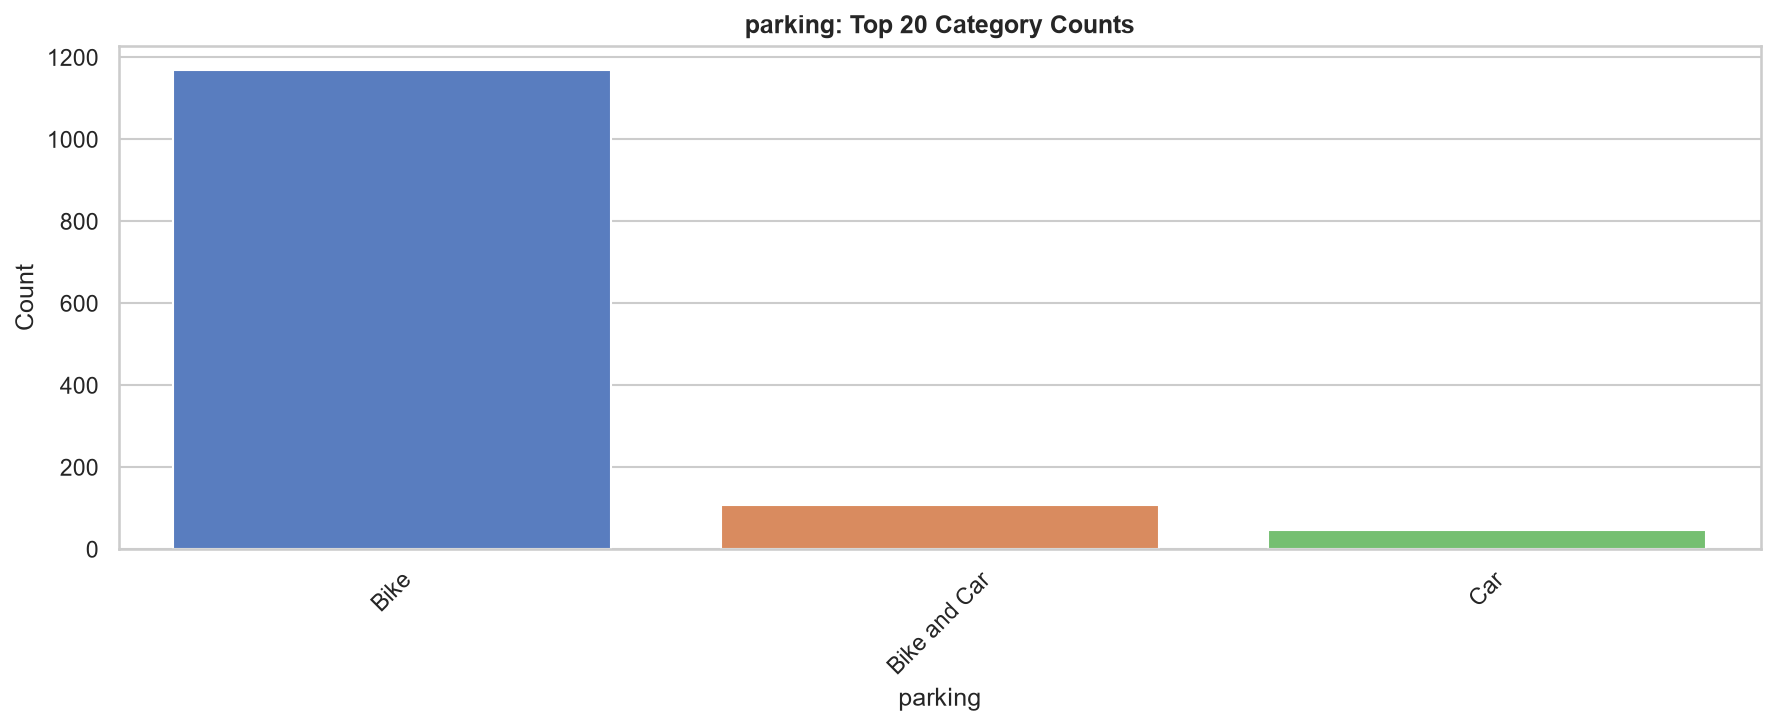

Saved: 08_cat_parking_counts.png


In [35]:
available_categorical = [c for c in CATEGORICAL_FEATURES if c in df.columns]
 
for col in available_categorical:
 
    vc = df[col].value_counts(dropna=False)
    vc_pct = df[col].value_counts(normalize=True, dropna=False) * 100
 
    summary_cat = pd.DataFrame({'Count': vc, 'Percent': vc_pct.round(2)})
    print(summary_cat.head(20).to_string())
    print(f'\nCardinality: {df[col].nunique(dropna=True)} unique values')
    print(f'Missing    : {df[col].isna().sum()} rows  ({df[col].isna().mean()*100:.2f}%)')
 
    # bar chart — top 20 categories
    top_n = 20
    top_vals = vc.head(top_n)
 
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(x=top_vals.index.astype(str), y=top_vals.values, ax=ax, palette=PALETTE)
    ax.set_title(f'{col}: Top {top_n} Category Counts', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
    save(fig, f'08_cat_{col}_counts')


In [36]:
# Locality: top 15 by listing count

if 'locality' in df.columns:
 
    top15_localities = df['locality'].value_counts().head(15)
    coverage = top15_localities.sum() / len(df) * 100
    print(f'Top 15 localities cover {coverage:.1f}% of all listings')
    print(top15_localities.to_string())


Top 15 localities cover 84.8% of all listings
locality
Tharamani                        240
OMR-Karappakam                   232
Velachery                        192
Sholinganallur                    94
Tambaram                          63
East Coast Road-Thiruvanmiyur     63
Saidapet                          61
Vadapalani                        54
New Perungalathur                 47
Karapakkam                        44
Thiruvanmiyur                     40
East Tambaram                     34
OMR-Sholinganallur                28
Arcot Road-Kodambakkam            28
Guindy                            27


# PHASE 3.4: FEATURE BY FEATURE ANALYSIS: BOOLEAN FEATURES

In [41]:
available_boolean = [c for c in BOOLEAN_FEATURES + INDICATOR_FEATURES if c in df.columns]
  
bool_summary = pd.DataFrame({
    'True Count': df[available_boolean].sum(),
    'True Percent': (df[available_boolean].mean() * 100).round(2),
    'False Count': (~df[available_boolean].astype(bool)).sum(),
}).sort_values('True Percent', ascending=False)
 
print(bool_summary.to_string())


                         True Count  True Percent  False Count
food_included                  1103         74.98          368
breakfast                      1079         73.35          392
dinner                         1075         73.08          396
lunch                          1054         71.65          417
transit_score_missing           768         52.21          703
lifestyle_score_missing         761         51.73          710
wifi                            632         42.96          839
room_cleaning                   587         39.90          884
refrigerator                    473         32.15          998
room_cupboard                   467         31.75         1004
room_attached_bath              461         31.34         1010
room_bedding                    446         30.32         1025
room_ac                         406         27.60         1065
laundry                         400         27.19         1071
mess                            371         25.22      

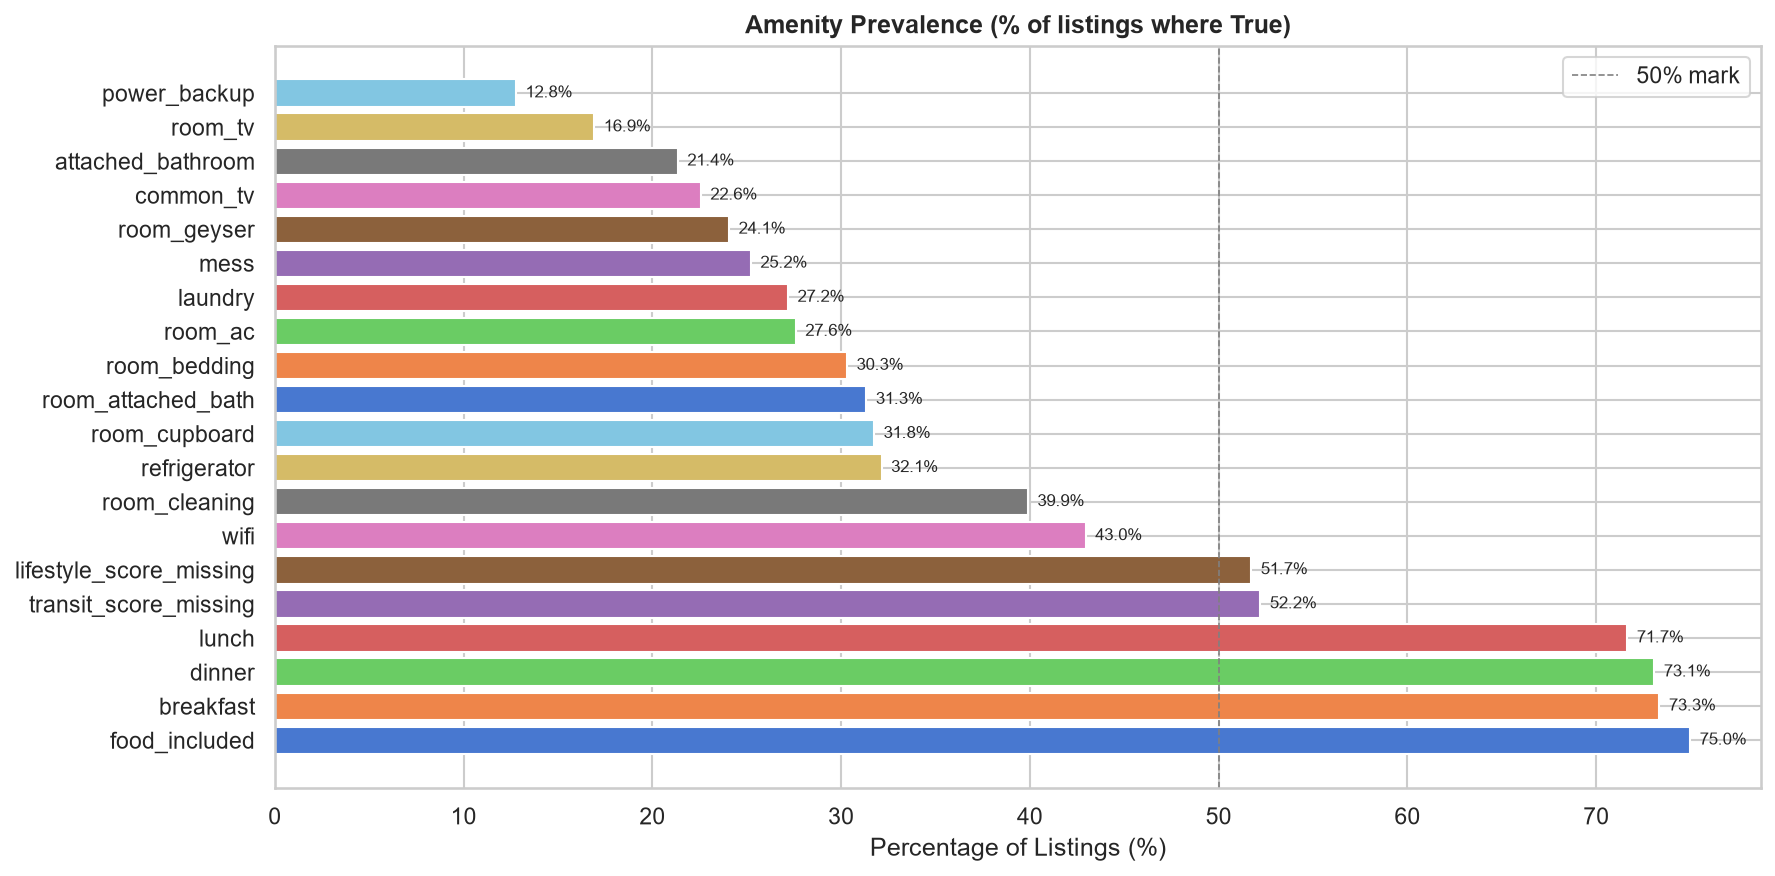

Saved: 09_boolean_prevalence.png


In [42]:
# Prevalence bar chart

fig, ax = plt.subplots(figsize=(12, 6))
 
bars = ax.barh(
    bool_summary.index,
    bool_summary['True Percent'],
    color=sns.color_palette(PALETTE, len(bool_summary))
)
ax.set_title('Amenity Prevalence (% of listings where True)', fontweight='bold')
ax.set_xlabel('Percentage of Listings (%)')
ax.axvline(50, color='gray', linestyle='--', linewidth=0.8, label='50% mark')
ax.legend()
 
for bar, val in zip(bars, bool_summary['True Percent']):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center',
        fontsize=8
    )

plt.tight_layout()
plt.show()
save(fig, '09_boolean_prevalence')

In [43]:
# Low variance flags

NEAR_ZERO_THRESHOLD = 5.0  # below 5% True is near-zero variance
HIGH_ONE_THRESHOLD  = 95.0  # above 95% True is near-constant
 
low_var = bool_summary[
    (bool_summary['True Percent'] < NEAR_ZERO_THRESHOLD) |
    (bool_summary['True Percent'] > HIGH_ONE_THRESHOLD)
]
 
if len(low_var) > 0:
    print('These boolean features have near-zero or near-constant variance.')
    print('They are unlikely to provide predictive signal and may be dropped in preprocessing.')
    print()
    print(low_var.to_string())
else:
    print('No boolean features flagged for low variance.')

No boolean features flagged for low variance.


# EDA Phase 3: Feature Analysis and Distribution Study

> **Purpose:** Understand the distribution, shape, and quality of every feature in the cleaned dataset.
> All decisions here drive the encoding and transformation choices in `03_preprocessing.ipynb`.
> No transformations or encodings are applied in this phase.

---

## Dataset State Entering Phase 3

- Source: `Data/processed/EDA/01_eda_Phase-2_processed.csv`
- Shape: 1471 rows x 31 columns
- All Phase 2 cleaning decisions have been applied

---

## 3.1 Target Variable Analysis: Rent

### Observations

- Rent is the regression target for the entire pipeline
- Distribution is heavily right skewed with skewness of approximately 3.72
- A small number of premium listings in areas like Nungambakkam and central OMR reach Rs. 40,000 to Rs. 65,000 and pull the mean far above the median
- The bulk of listings sit between Rs. 6,000 and Rs. 12,000, which is the budget to mid range segment of the Chennai PG market
- The Shapiro Wilk normality test p value falls far below 0.05
- Kurtosis is elevated, confirming the presence of extreme values relative to a normal distribution
- IQR outlier inspection (1.5x multiplier) flags listings above approximately Rs. 18,000 to Rs. 22,000 as statistical outliers
- These outliers are genuine premium listings, not errors

### Log Transform Assessment

- After `np.log1p()`, skewness drops to near zero
- The log transformed distribution closely approximates a symmetric bell shape
- Inverse transform via `np.expm1()` recovers the original rent scale after prediction

### Rent by Occupancy

- Single occupancy has the highest median rent
- Four sharing has the lowest median rent
- Distributions overlap considerably across tiers
- The gap between single and double is not proportional to the gap between double and three sharing — the relationship is non linear

### Decisions

| Issue | Decision | Rationale |
|---|---|---|
| Right skew (skewness ~3.72) | Apply `np.log1p(rent)` before linear models | Normality assumption violated without transformation |
| IQR outliers (premium listings) | Retain through EDA | These are real high end listings, not errors. Revisit at modelling stage |
| Non normality confirmed by Shapiro Wilk | Log transform is mandatory for linear and regularised models | Tree models (RF, XGBoost) can optionally skip |

---

## 3.2 Numeric Feature Analysis

### 3.2.1 Deposit

#### Observations

- Strongly correlated with rent PGs typically set deposit as one to three months of monthly rent
- Skewness is approximately 11.0, more severe than rent
- Median deposit is in the range of Rs. 3,000 to Rs. 5,000
- Maximum deposit reaches Rs. 200,000 a 40x to 67x gap from median to max
- Deposit to rent ratio clusters between 1.0 and 3.0 for the majority of listings, confirming standard pricing convention
- A small number of outlier ratios suggest possible data entry errors in deposit values
- One row has deposit equal to zero, confirmed to be 0.1% of listings non issue

#### Decisions

| Issue | Decision | Rationale |
|---|---|---|
| Extreme right skew (skewness ~11.0) | Apply `np.log1p(deposit)` | Same reasoning as rent |
| Deposit zero row (1 row, 0.1%) | Retain | Negligible impact |
| Outlier deposit values | Retain, let log transform compress | Capping deferred to modelling stage |

---

### 3.2.2 Transit Score

#### Observations

- After Phase 2 cleaning: sentinel value of negative ten replaced with NaN, then imputed via locality median and global median fallback
- Distribution is moderately left skewed after cleaning
- Most listings score in the mid to high transit range, consistent with urban Chennai concentration
- `transit_score_missing` indicator records the substantial block of rows that had no original score
- These missing rows correspond to peripheral or less indexed localities

#### Decisions

| Issue | Decision |
|---|---|
| Distribution shape after cleaning | No further transformation needed, use as is |
| Missingness pattern | Captured by `transit_score_missing` indicator retain this column |

---

### 3.2.3 Lifestyle Score

#### Observations

- Mild left skew, approximately negative 0.57 after cleaning, close to symmetric
- Longer lower tail than transit score some localities score very low on lifestyle amenities
- Missing for the exact same rows as transit score (peripheral areas NoBroker has not indexed)
- `lifestyle_score_missing` indicator captures this pattern

#### Decisions

| Issue | Decision |
|---|---|
| Near symmetric distribution | No transformation needed, use as is |
| Missingness pattern | Captured by `lifestyle_score_missing` indicator retain this column |

---

## 3.3 Categorical Feature Analysis

### 3.3.1 Locality

#### Observations

- 36 unique values, no missing entries
- Top 15 localities account for approximately 80 to 90 percent of all listings
- Several localities have extremely low listing counts:

| Locality | Approximate Count |
|---|---|
| Adyar | 1 |
| Shanthi Nagar | 1 |
| Padapai | 2 |
| Vinayagapuram | 4 |
| Mannivakkam | 4 |

- A naive target encoding mean from 1 listing is statistically meaningless and creates an unstable estimate
- Geographic concentration is in IT corridor areas: Tharamani, Velachery, Perungalathur, OMR, Porur

#### Decisions

| Issue | Decision | Rationale |
|---|---|---|
| 36 categories too wide for OHE | Use smoothed target encoding | OHE would create 35 sparse binary columns |
| Sparse localities (1 to 4 listings) | Apply smoothing during target encoding | Blends locality mean with global mean, weighted by count |
| Encoding scale | Encode using `rent_log` values, not raw rent | Model trains on log scale; encoding must match |

**Smoothed Target Encoding Formula:**

```python
smoothing = 10  # tune this weight
global_mean = y_train.mean()

stats = X_train.groupby('locality')['rent_log'].agg(['mean', 'count'])
smoothed = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)

X_train['locality_encoded'] = X_train['locality'].map(smoothed)
X_test['locality_encoded'] = X_test['locality'].map(smoothed).fillna(global_mean)
```

---

### 3.3.2 Gender

#### Observations

- 3 categories: male only, female only, any gender
- No missing values
- Nominal no ordering exists between categories

#### Decisions

| Issue | Decision |
|---|---|
| Low cardinality nominal feature | OHE with `drop='first'` |

---

### 3.3.3 Available For

#### Observations

- 3 categories: bachelors, families, both
- No missing values
- Nominal no ordering exists between categories

#### Decisions

| Issue | Decision |
|---|---|
| Low cardinality nominal feature | OHE with `drop='first'` |

---

### 3.3.4 Occupancy

#### Observations

- 4 categories after Phase 2 NaN row drops: single, double, three sharing, four sharing
- Single rooms are least common, four sharing appears frequently (student and professional segment)
- The rent difference between sharing tiers is non linear confirmed by Section 3.1 boxplot
- Imposing ordinal encoding would force a false linear constraint on the model

#### Decisions

| Issue | Decision | Rationale |
|---|---|---|
| Looks ordinal but relationship with rent is non linear | OHE with `drop='first'` | Ordinal encoding would be incorrect |

---

### 3.3.5 Parking

#### Observations

- 4 categories after Phase 2 `fillna('None')`: None, Bike, Car, Bike and Car
- Majority of listings have no parking urban Chennai properties are space constrained
- Nominal no ordering exists between parking types

#### Decisions

| Issue | Decision |
|---|---|
| Low cardinality nominal feature | OHE with `drop='first'` |

---

## 3.4 Boolean and Indicator Feature Analysis

### 3.4.1 Amenity Prevalence

#### Observations

- 18 boolean amenity columns analysed for True percentage
- General pattern: budget PG market has uneven amenity provision
- Features near universal (attached bathroom, wifi) carry less discriminating power
- Features rare across listings (refrigerator, common TV, room geyser) may show near zero variance

#### Low Variance Flagging

- Threshold used: below 5% True or above 95% True flagged as near constant
- Features flagged here are candidates for removal in preprocessing
- Final drop decision deferred to Phase 4 a rare amenity may still show a strong rent signal

#### Decisions

| Issue | Decision |
|---|---|
| Boolean features stored as Python bool dtype | Cast all to int64 before sklearn (`df[bool_cols].astype(int)`) |
| Near zero variance features flagged | Do not drop yet confirm in Phase 4 feature vs target analysis first |
| Food redundancy (breakfast, lunch, dinner highly correlated with food_included) | Drop breakfast, lunch, dinner — retain food_included and mess |

> **Critical note on sklearn:** `astype(bool)` dtype causes silent misbehaviour in sklearn Pipeline, StandardScaler, and most transformers. Always cast to int64 before any sklearn step.

---

### 3.4.2 Indicator Columns

#### Observations

- `transit_score_missing` and `lifestyle_score_missing` both show the same True count
- This confirms both scores were absent for the exact same set of rows
- These rows correspond to peripheral or unindexed localities

#### Decisions

| Issue | Decision |
|---|---|
| Already binary int64 | Retain as is, no encoding needed |

---

## Complete Encoding Decision Summary

| Column | Dtype | Cardinality | Technique | Decision |
|---|---|---|---|---|
| `id` | str | unique per row | Drop | Identifier, zero signal |
| `title` | str | high | Drop | Free text, redundant with locality |
| `address` | str | unique per row | Drop | Redundant with lat/lon and locality |
| `gate_closing_time` | str | ~80% missing | Drop | Too sparse |
| `total_bathrooms` | float64 | 50% zeros | Drop | Building level, not room level |
| `breakfast`, `lunch`, `dinner` | bool | binary | Drop | Redundant with food_included (corr > 0.93) |
| `latitude` | float64 | continuous | Keep as is | Numeric coordinate |
| `longitude` | float64 | continuous | Keep as is | Numeric coordinate |
| `transit_score` | float64 | continuous | Keep as is | Already imputed and cleaned |
| `lifestyle_score` | float64 | continuous | Keep as is | Already imputed |
| `rent` | float64 | continuous | `log1p` transform | Skewness ~3.72 |
| `deposit` | float64 | continuous | `log1p` transform | Skewness ~11.0 |
| `gender` | str | 3 | OHE drop first | Nominal, no order |
| `available_for` | str | 3 | OHE drop first | Nominal, no order |
| `occupancy` | str | 4 | OHE drop first | Non linear rent relationship |
| `parking` | str | 4 | OHE drop first | Nominal, no order |
| `locality` | str | 36 | Smoothed target encoding | High cardinality, strong rent signal, sparse localities |
| 15 bool amenity cols | bool | binary | Cast to int64 | sklearn compatibility |
| `transit_score_missing` | int64 | binary | Keep as is | Already encoded indicator |
| `lifestyle_score_missing` | int64 | binary | Keep as is | Already encoded indicator |

---

## What Has Been Deferred to Phase 4

| Analysis | Reason for Deferral |
|---|---|
| Feature vs rent bivariate relationships | Requires Phase 3 analysis to be complete first |
| Correlation matrix across all numeric features | Needed to detect multicollinearity before modelling |
| Final decision on near zero variance boolean features | Needs rent relationship check before dropping |
| Feature importance ranking (diagnostic tree model) | Data driven validation of encoding decisions |

---

> **Next:** `04_EDA_Phase4.ipynb` — relationship analysis, correlation matrix, and diagnostic feature importance.
> All decisions above are executed in `03_preprocessing.ipynb` after Phase 4 is complete.